
## 1. Write a Python program to generate a random variable and display its value.



In [ ]:
import random

random_variable = random.randint(1, 100)

print("Generated Random Variable:", random_variable)


Generated Random Variable: 78


## 2. Generate a discrete uniform distribution using Python and plot the probability mass function (PMF).

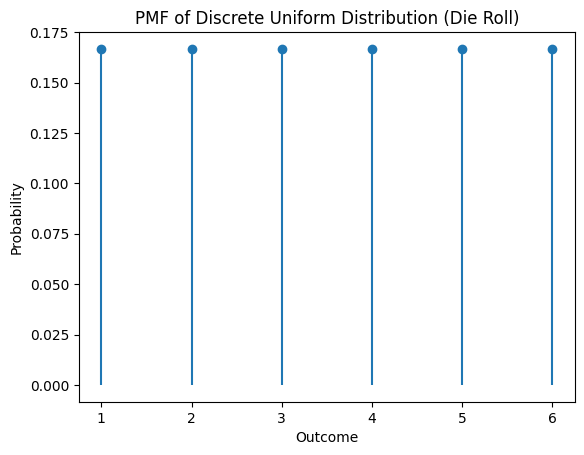

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


x = np.arange(1, 7)
pmf = np.ones_like(x) / len(x)

plt.stem(x, pmf, basefmt=" ")
plt.title("PMF of Discrete Uniform Distribution (Die Roll)")
plt.xlabel("Outcome")
plt.ylabel("Probability")
plt.show()


## 3. Write a Python function to calculate the probability distribution function (PDF) of a Bernoulli distribution.

In [ ]:
def bernoulli_pmf(x, p):
    """
    PMF of Bernoulli distribution
    x : 0 or 1
    p : probability of success
    """
    if x not in [0, 1]:
        return 0
    return p**x * (1 - p)**(1 - x)

# Example
p = 0.6
print("P(X=0):", bernoulli_pmf(0, p))
print("P(X=1):", bernoulli_pmf(1, p))


P(X=0): 0.4
P(X=1): 0.6


## 4. Write a Python script to simulate a binomial distribution with n=10 and p=0.5, then plot its histogram.

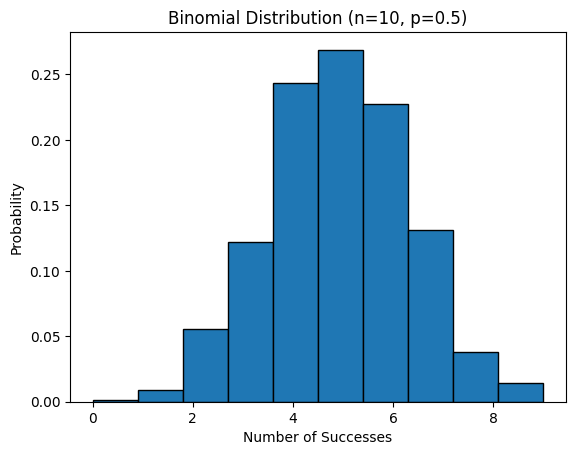

In [ ]:
from numpy.random import binomial


n = 10
p = 0.5
size = 1000

data = binomial(n, p, size)

plt.hist(data, density=True, edgecolor="black")
plt.title("Binomial Distribution (n=10, p=0.5)")
plt.xlabel("Number of Successes")
plt.ylabel("Probability")
plt.show()


## 5. Create a Poisson distribution and visualize it using Python.

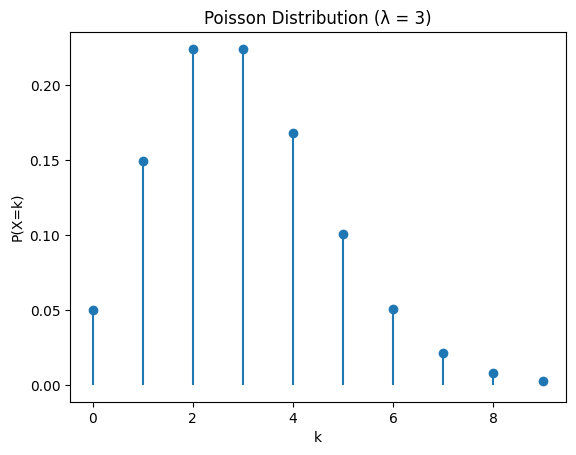

In [ ]:
from scipy.stats import poisson


lam = 3

x = np.arange(0, 10)
pmf = poisson.pmf(x, lam)

plt.stem(x, pmf, basefmt=" ")
plt.title("Poisson Distribution (λ = 3)")
plt.xlabel("k")
plt.ylabel("P(X=k)")
plt.show()


### 6. Write a Python program to calculate and plot the cumulative distribution function (CDF) of a discrete uniform distribution.

x=1, PMF=0.167, CDF=0.167
x=2, PMF=0.167, CDF=0.333
x=3, PMF=0.167, CDF=0.500
x=4, PMF=0.167, CDF=0.667
x=5, PMF=0.167, CDF=0.833
x=6, PMF=0.167, CDF=1.000


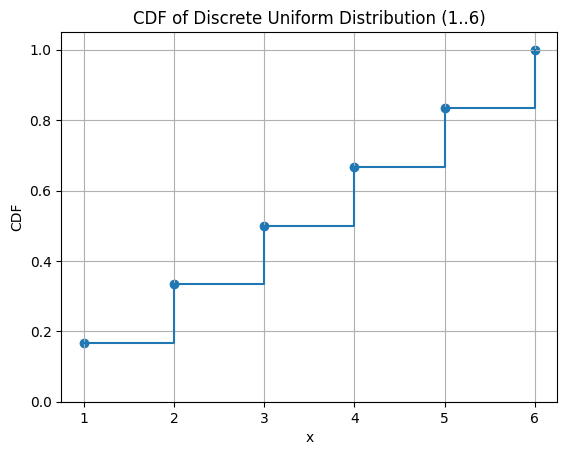

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


values = np.arange(1, 7)
pmf = np.ones_like(values) / len(values)
cdf = np.cumsum(pmf)

for v, p, c in zip(values, pmf, cdf):
    print(f"x={v}, PMF={p:.3f}, CDF={c:.3f}")

plt.step(values, cdf, where='post')
plt.scatter(values, cdf)
plt.ylim(0, 1.05)
plt.xlabel("x")
plt.ylabel("CDF")
plt.title("CDF of Discrete Uniform Distribution (1..6)")
plt.grid(True)
plt.show()


### 7. Generate a continuous uniform distribution using NumPy and visualize it.

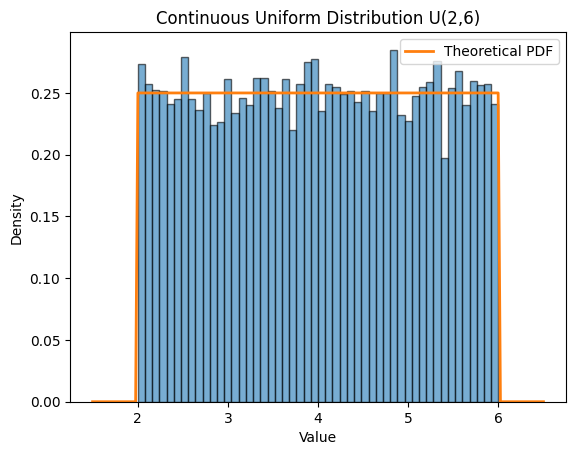

Sample mean: 3.9993919466637045 Theoretical mean: 4.0
Sample var:  1.3384078164207747 Theoretical var: 1.3333333333333333


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a, b = 2.0, 6.0
size = 10000
data = np.random.uniform(a, b, size)

plt.hist(data, bins=50, density=True, edgecolor='k', alpha=0.6)

xs = np.linspace(a-0.5, b+0.5, 200)
pdf = np.where((xs >= a) & (xs <= b), 1/(b-a), 0)
plt.plot(xs, pdf, lw=2, label='Theoretical PDF')

plt.title("Continuous Uniform Distribution U(2,6)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

print("Sample mean:", data.mean(), "Theoretical mean:", (a+b)/2)
print("Sample var: ", data.var(), "Theoretical var:", (b-a)**2/12)


## 8. Simulate data from a normal distribution and plot its histogram.

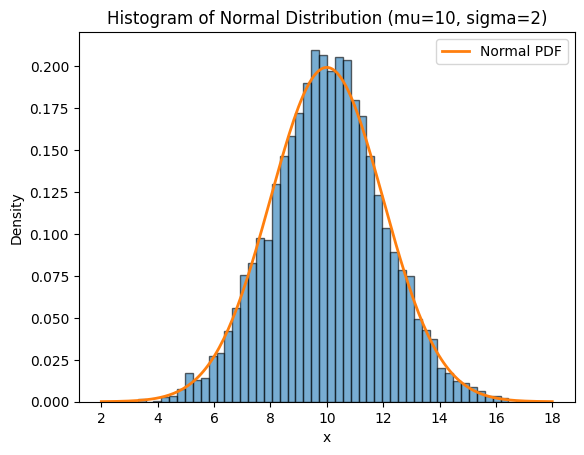

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu, sigma = 10, 2
data = np.random.normal(mu, sigma, 5000)

plt.hist(data, bins=50, density=True, alpha=0.6, edgecolor='k')
xs = np.linspace(mu-4*sigma, mu+4*sigma, 200)
plt.plot(xs, norm.pdf(xs, mu, sigma), lw=2, label='Normal PDF')
plt.title("Histogram of Normal Distribution (mu=10, sigma=2)")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.show()



## 9. Write a Python function to calculate Z-scores from a dataset and plot them.

Data: [45 52 47 50 49 60 55 48 46 53]
Z-scores: [-1.26   0.344 -0.802 -0.115 -0.344  2.177  1.031 -0.573 -1.031  0.573]


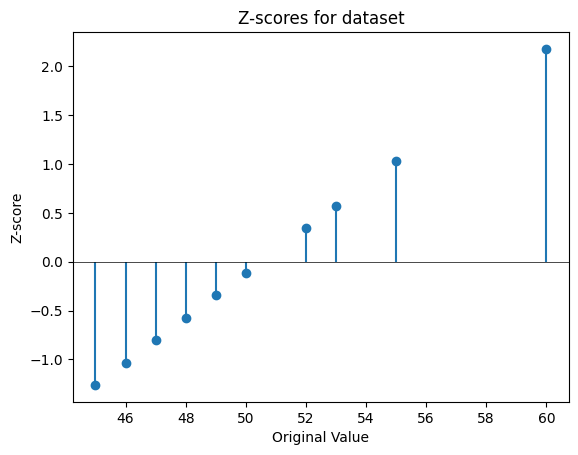

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def z_scores(arr):
    arr = np.array(arr, dtype=float)
    mu = arr.mean()
    sigma = arr.std(ddof=0)
    return (arr - mu) / sigma

# Example dataset
data = np.array([45, 52, 47, 50, 49, 60, 55, 48, 46, 53])
zs = z_scores(data)
print("Data:", data)
print("Z-scores:", np.round(zs, 3))

plt.stem(data, zs, basefmt=" ")
plt.axhline(0, color='k', linewidth=0.5)
plt.xlabel("Original Value")
plt.ylabel("Z-score")
plt.title("Z-scores for dataset")
plt.show()

## 10. Implement the Central Limit Theorem (CLT) using Python for a non-normal distribution.

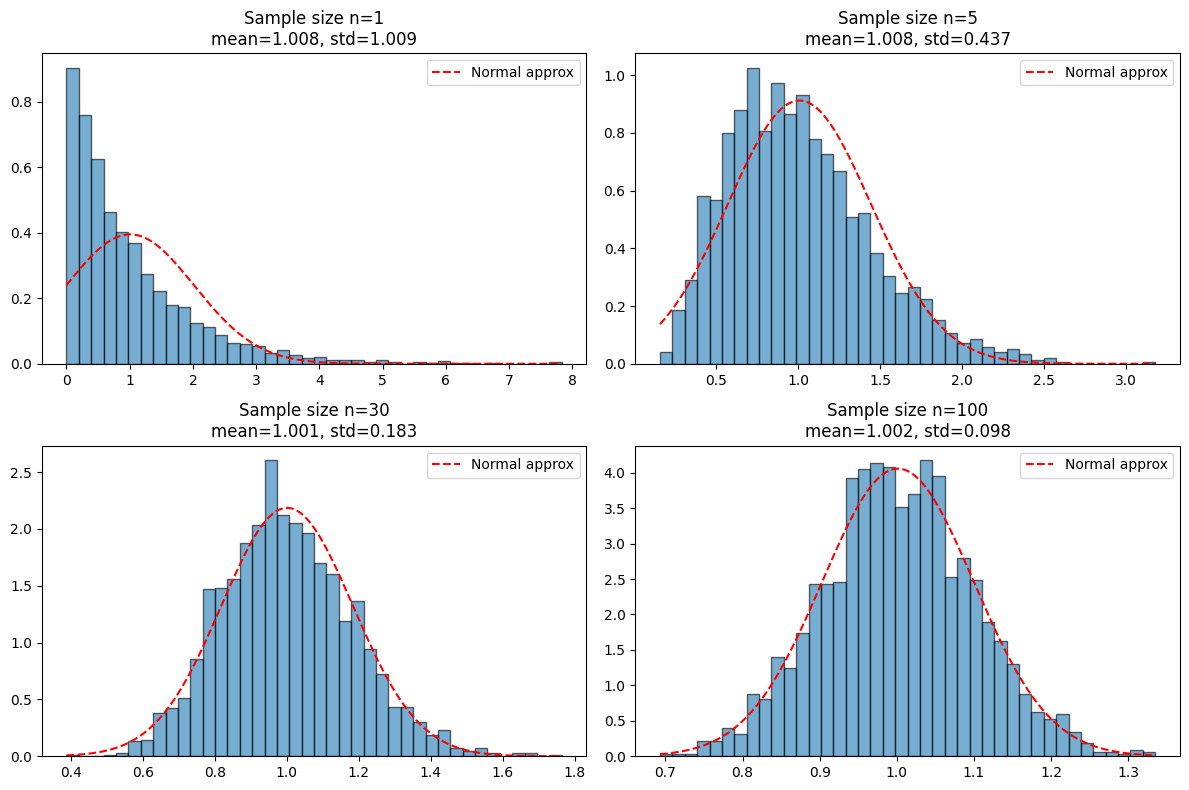

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Non-normal distribution: exponential with scale=1
pop = np.random.exponential(scale=1.0, size=1000000)

def sample_means(sample_size, n_samples):
    means = []
    for _ in range(n_samples):
        s = np.random.choice(pop, size=sample_size, replace=False)
        means.append(s.mean())
    return np.array(means)

sample_sizes = [1, 5, 30, 100]
plt.figure(figsize=(12,8))
for i, n in enumerate(sample_sizes, 1):
    means = sample_means(n, 2000)
    plt.subplot(2,2,i)
    plt.hist(means, bins=40, density=True, alpha=0.6, edgecolor='k')
    mu, sigma = means.mean(), means.std()
    xs = np.linspace(means.min(), means.max(), 200)
    plt.plot(xs, norm.pdf(xs, mu, sigma), 'r--', label='Normal approx')
    plt.title(f"Sample size n={n}\nmean={mu:.3f}, std={sigma:.3f}")
    plt.legend()
plt.tight_layout()
plt.show()


## 11. Simulate multiple samples from a normal distribution and verify the Central Limit Theorem.

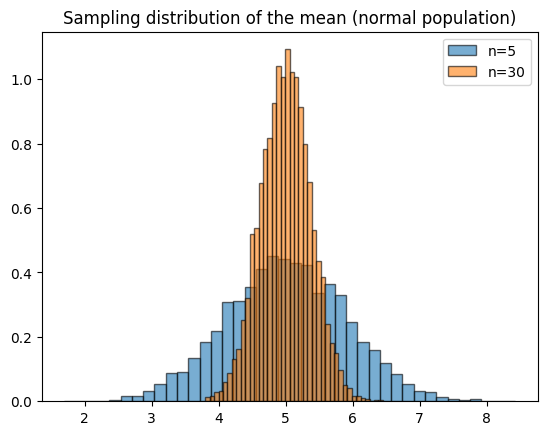

mean n=5: 5.01188754994157 std n=5: 0.893306057298303
mean n=30: 4.996948253668744 std n=30: 0.37148314806204885


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

population = np.random.normal(loc=5, scale=2, size=1000000)

def many_sample_means(n, m):
    return np.mean(np.random.choice(population, size=(m,n)), axis=1)

means_n5 = many_sample_means(5, 5000)
means_n30 = many_sample_means(30, 5000)

plt.hist(means_n5, bins=40, density=True, alpha=0.6, edgecolor='k', label='n=5')
plt.hist(means_n30, bins=40, density=True, alpha=0.6, edgecolor='k', label='n=30')
plt.legend()
plt.title("Sampling distribution of the mean (normal population)")
plt.show()

print("mean n=5:", means_n5.mean(), "std n=5:", means_n5.std())
print("mean n=30:", means_n30.mean(), "std n=30:", means_n30.std())


## 12. Write a Python function to calculate and plot the standard normal distribution (mean=0, std=1).

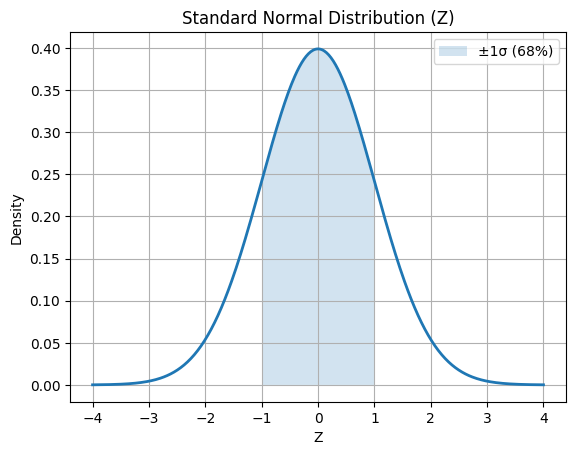

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

xs = np.linspace(-4, 4, 400)
ys = norm.pdf(xs, 0, 1)

plt.plot(xs, ys, lw=2)
plt.fill_between(xs, ys, where=(xs >= -1) & (xs <= 1), alpha=0.2, label='±1σ (68%)')
plt.title("Standard Normal Distribution (Z)")
plt.xlabel("Z")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


## 13. Generate random variables and calculate their corresponding probabilities using the binomial distribution.

P(X=0) = 0.0282
P(X=1) = 0.1211
P(X=2) = 0.2335
P(X=3) = 0.2668
P(X=4) = 0.2001
P(X=5) = 0.1029
P(X=6) = 0.0368
P(X=7) = 0.0090
P(X=8) = 0.0014
P(X=9) = 0.0001
P(X=10) = 0.0000


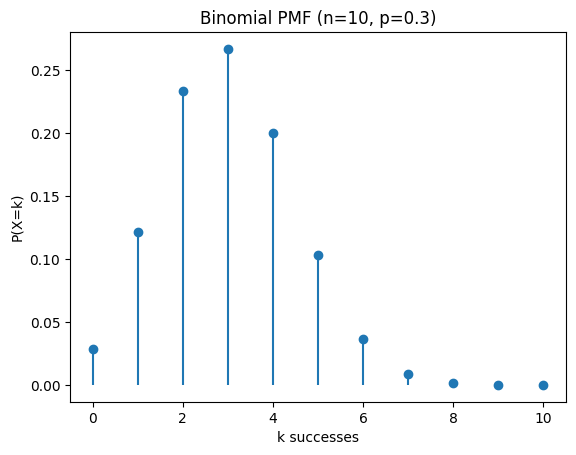

In [4]:
import numpy as np
from scipy.stats import binom

n, p = 10, 0.3
k_vals = np.arange(0, n+1)
pmf = binom.pmf(k_vals, n, p)

for k, prob in zip(k_vals, pmf):
    print(f"P(X={k}) = {prob:.4f}")

# Plot
import matplotlib.pyplot as plt
plt.stem(k_vals, pmf, basefmt=" ")
plt.title(f"Binomial PMF (n={n}, p={p})")
plt.xlabel("k successes")
plt.ylabel("P(X=k)")
plt.show()


## 14. Write a Python program to calculate the Z-score for a given data point and compare it to a standard normal distribution.

Z-score of 62 is 2.324381425388871
P(Z > observed) = 0.010052530096919088


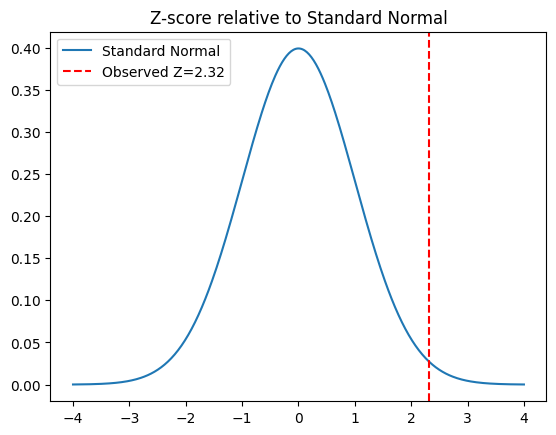

In [5]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

def z_score_of_point(x, data):
    mu = np.mean(data)
    sigma = np.std(data, ddof=0)
    return (x - mu) / sigma

# Example
data = np.random.normal(50, 5, 500)
x = 62
z = z_score_of_point(x, data)
print("Z-score of", x, "is", z)

# Compare to standard normal: compute tail probability
tail_prob = 1 - norm.cdf(z)
print("P(Z > observed) =", tail_prob)

# Visualize
xs = np.linspace(-4, 4, 400)
plt.plot(xs, norm.pdf(xs), label='Standard Normal')
plt.axvline(z, color='r', linestyle='--', label=f'Observed Z={z:.2f}')
plt.legend()
plt.title("Z-score relative to Standard Normal")
plt.show()


## 15. Implement hypothesis testing using Z-statistics for a sample dataset.

In [6]:
import numpy as np
from scipy.stats import norm

# Given population sigma known
sigma = 10  # known population sd
mu0 = 100   # Null hypothesis mean
sample = np.array([105, 98, 102, 110, 95, 99, 101, 104])
n = len(sample)
xbar = sample.mean()

# Z statistic
Z = (xbar - mu0) / (sigma / np.sqrt(n))
alpha = 0.05
z_crit = norm.ppf(1 - alpha/2)

print("Sample mean:", xbar)
print("Z-statistic:", Z)
print("Critical z (two-tailed, 0.05): ±", z_crit)

if abs(Z) > z_crit:
    print("Reject H0")
else:
    print("Fail to reject H0")


Sample mean: 101.75
Z-statistic: 0.4949747468305833
Critical z (two-tailed, 0.05): ± 1.959963984540054
Fail to reject H0


## 16. Create a confidence interval for a dataset using Python and interpret the result.

In [7]:
import numpy as np
from scipy import stats

sample = np.array([52, 47, 50, 55, 49, 48, 54, 51])
n = len(sample)
alpha = 0.05
df = n - 1
xbar = sample.mean()
s = sample.std(ddof=1)

t_crit = stats.t.ppf(1-alpha/2, df)
se = s / np.sqrt(n)
ci_lower = xbar - t_crit * se
ci_upper = xbar + t_crit * se

print(f"Sample mean = {xbar:.3f}")
print(f"95% CI = [{ci_lower:.3f}, {ci_upper:.3f}]")


Sample mean = 50.750
95% CI = [48.396, 53.104]


## 17. Generate data from a normal distribution, then calculate and interpret the confidence interval for its mean.

In [8]:
import numpy as np
from scipy import stats

np.random.seed(0)
data = np.random.normal(loc=200, scale=15, size=40)  # population approx normal
n = len(data)
xbar = data.mean()
s = data.std(ddof=1)
alpha = 0.05
t_crit = stats.t.ppf(1-alpha/2, n-1)
se = s / np.sqrt(n)
ci = (xbar - t_crit*se, xbar + t_crit*se)

print("Sample mean:", xbar)
print("95% CI:", ci)


Sample mean: 204.68813709824258
95% CI: (np.float64(199.51723449461198), np.float64(209.85903970187317))


## 18. Write a Python script to calculate and visualize the probability density function (PDF) of a normal distribution.

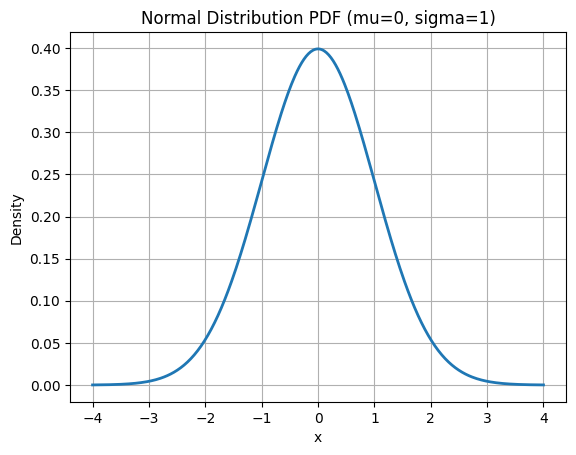

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu, sigma = 0, 1
xs = np.linspace(-4, 4, 400)
ys = norm.pdf(xs, mu, sigma)

plt.plot(xs, ys, lw=2)
plt.title("Normal Distribution PDF (mu=0, sigma=1)")
plt.xlabel("x")
plt.ylabel("Density")
plt.grid(True)
plt.show()


## 19. Use Python to calculate and interpret the cumulative distribution function (CDF) of a Poisson distribution.

P(X <= 6) for Poisson(λ=4) = 0.8893260215974264


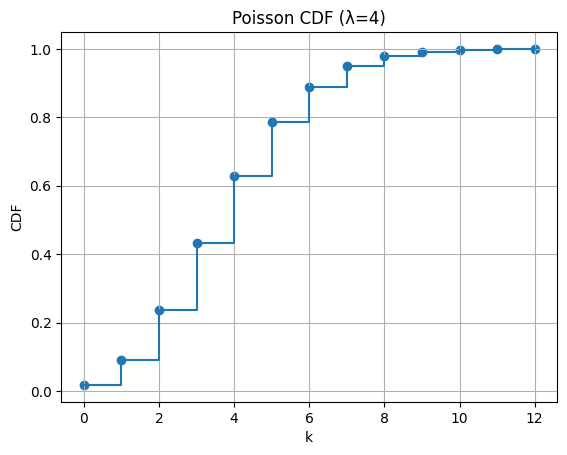

In [10]:
import numpy as np
from scipy.stats import poisson

lam = 4
k = 6
# P(X <= k)
cdf_val = poisson.cdf(k, lam)
print(f"P(X <= {k}) for Poisson(λ={lam}) =", cdf_val)

# Plot CDF for k=0..12
import matplotlib.pyplot as plt
ks = np.arange(0, 13)
cdf_vals = poisson.cdf(ks, lam)
plt.step(ks, cdf_vals, where='post')
plt.scatter(ks, cdf_vals)
plt.xlabel("k")
plt.ylabel("CDF")
plt.title(f"Poisson CDF (λ={lam})")
plt.grid(True)
plt.show()


## 20. Simulate a random variable using a continuous uniform distribution and calculate its expected value.

In [11]:
import numpy as np

a, b = 0, 10
data = np.random.uniform(a, b, size=1000000)
sample_mean = data.mean()
theoretical_mean = (a+b)/2

print("Sample mean:", sample_mean)
print("Theoretical expected value:", theoretical_mean)


Sample mean: 5.003840376925114
Theoretical expected value: 5.0


## 21. Write a Python program to compare the standard deviations of two datasets and visualize the difference.

Std dev dataset1: 5.1080639604089875
Std dev dataset2: 10.12317918571212


/tmp/ipython-input-699484054.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data1, data2], labels=['Data1 (sd~5)', 'Data2 (sd~10)'])


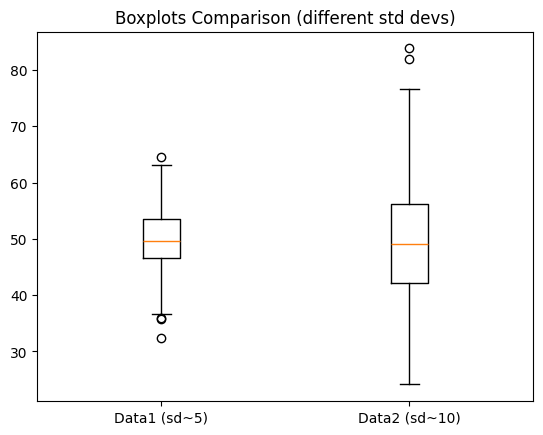

In [12]:
import numpy as np
import matplotlib.pyplot as plt

data1 = np.random.normal(50, 5, 400)
data2 = np.random.normal(50, 10, 400)

std1 = data1.std(ddof=1)
std2 = data2.std(ddof=1)
print("Std dev dataset1:", std1)
print("Std dev dataset2:", std2)

plt.boxplot([data1, data2], labels=['Data1 (sd~5)', 'Data2 (sd~10)'])
plt.title("Boxplots Comparison (different std devs)")
plt.show()


## 22. Calculate the range and interquartile range (IQR) of a dataset generated from a normal distribution.

In [13]:
import numpy as np
from scipy import stats

data = np.random.normal(100, 15, 500)
data_range = data.max() - data.min()
q1, q3 = np.percentile(data, [25, 75])
iqr = q3 - q1

print("Range:", data_range)
print("IQR:", iqr)


Range: 110.32508558687114
IQR: 19.814111070176565


## 23. Implement Z-score normalization on a dataset and visualize its transformation.

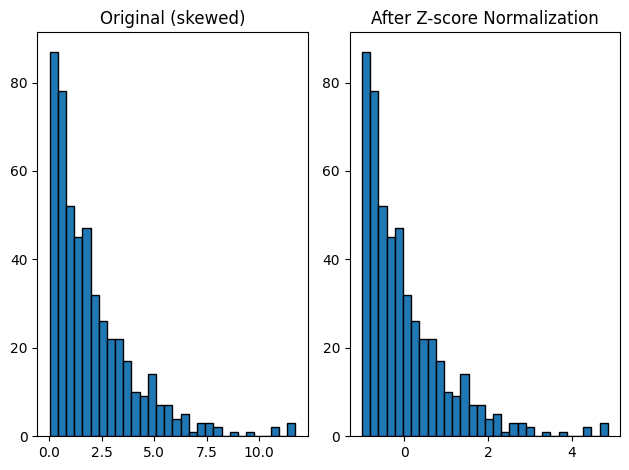

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

data = np.random.exponential(scale=2.0, size=500).reshape(-1,1)  # skewed data
scaler = StandardScaler()
zdata = scaler.fit_transform(data).flatten()

plt.subplot(1,2,1)
plt.hist(data.flatten(), bins=30, edgecolor='k')
plt.title("Original (skewed)")

plt.subplot(1,2,2)
plt.hist(zdata, bins=30, edgecolor='k')
plt.title("After Z-score Normalization")
plt.tight_layout()
plt.show()


## 24. Write a Python function to calculate the skewness and kurtosis of a dataset generated from a normal distribution.

In [15]:
import numpy as np
from scipy.stats import skew, kurtosis

data = np.random.normal(loc=0, scale=1, size=1000)
print("Sample skewness:", skew(data))
print("Sample kurtosis (excess):", kurtosis(data))  # excess kurtosis


Sample skewness: 0.043407504336054094
Sample kurtosis (excess): -0.11097825084242618


## 25. Write a Python program to compare the standard deviations of two datasets and visualize the difference.

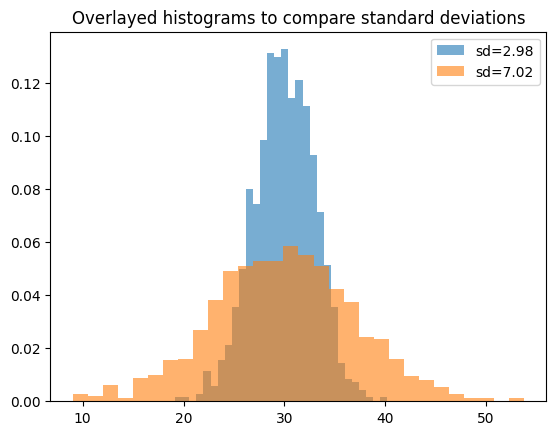

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data1 = np.random.normal(30, 3, 1000)
data2 = np.random.normal(30, 7, 1000)

plt.hist(data1, bins=30, alpha=0.6, density=True, label=f'sd={data1.std(ddof=1):.2f}')
plt.hist(data2, bins=30, alpha=0.6, density=True, label=f'sd={data2.std(ddof=1):.2f}')
plt.legend()
plt.title("Overlayed histograms to compare standard deviations")
plt.show()


## 26. Calculate the range and interquartile range (IQR) of a dataset generated from a normal distribution.

In [2]:
import numpy as np

data = np.random.normal(0, 1, 1000)
data_range = data.max() - data.min()
q1, q3 = np.percentile(data, [25, 75])
iqr = q3 - q1
print("Range:", data_range)
print("IQR:", iqr)


Range: 6.758514012112705
IQR: 1.3535215887187673


## 27. Implement Z-score normalization on a dataset and visualize its transformation.

Before normalization:
              A         B
mean  4.124252  9.952198
std   2.831646  2.845382

After normalization:
                  A             B
mean -1.705303e-16 -1.101341e-16
std   1.001002e+00  1.001002e+00


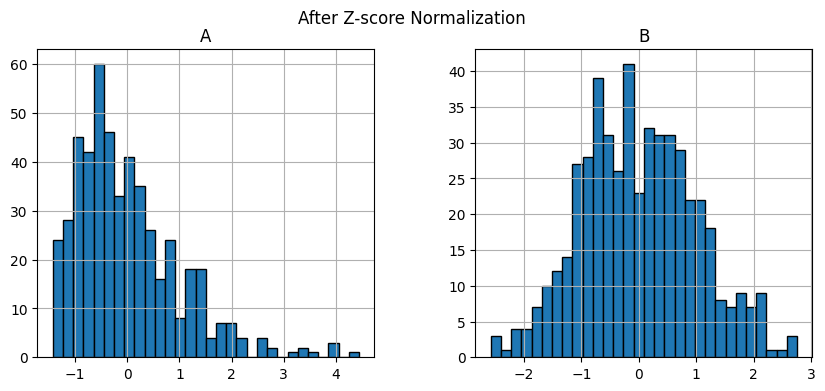

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'A': np.random.gamma(2, 2, 500),
    'B': np.random.normal(10, 3, 500)
})
print("Before normalization:\n", df.describe().loc[['mean','std']])

z_df = (df - df.mean()) / df.std(ddof=0)
print("\nAfter normalization:\n", z_df.describe().loc[['mean','std']])

z_df.hist(bins=30, layout=(1,2), figsize=(10,4), edgecolor='k')
plt.suptitle("After Z-score Normalization")
plt.show()


## 28. Write a Python function to calculate the skewness and kurtosis of a dataset generated from a normal distribution.

Skewness: 0.10984689315338823
Excess Kurtosis: 0.17788541588415763


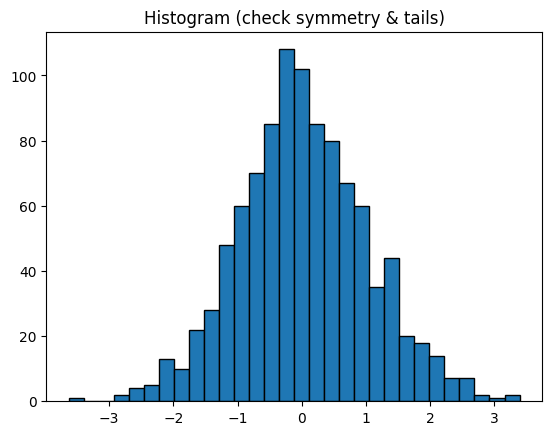

In [4]:
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt

def skew_kurt(data):
    return skew(data), kurtosis(data)

data = np.random.normal(0, 1, 1000)
s, k = skew_kurt(data)
print("Skewness:", s)
print("Excess Kurtosis:", k)

# Visual check: histogram
plt.hist(data, bins=30, edgecolor='k')
plt.title("Histogram (check symmetry & tails)")
plt.show()
